In [ ]:
import tensorflow as tf

gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU está disponível!")
    print("Nome da GPU:", gpu_available[0].name)
else:
    print("GPU não está disponível")

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import pickle as pkl
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard

In [4]:
# Additional imports for CNN model
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, GlobalAveragePooling1D
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.regularizers import l2

In [5]:
with open('../output/train_minds.pkl', 'rb') as f:
    input_train, output_train = pkl.load(f)


In [6]:
max_timesteps = max(x.shape[0] for x in input_train)
max_timesteps

46

In [7]:
input_train_padded = pad_sequences(input_train, maxlen=max_timesteps, padding='post', dtype='float32')

In [8]:
unique_labels = np.unique(output_train)
num_classes = len(unique_labels)
label_to_int = {label: i for i, label in enumerate(np.unique(output_train))}
output_numeric = np.array([label_to_int[label] for label in output_train])
output_categorical = to_categorical(output_numeric, num_classes=num_classes)

In [ ]:
# CNN Model for Sequential Data 
def create_cnn_model(max_timesteps, num_features, num_classes):
    """
    Create a 1D CNN model for temporal sequence classification
    This treats the time series as a 1D signal and applies convolutions across time
    """
    model = Sequential()
    
    # Input shape: (batch_size, timesteps, features)
    model.add(Masking(mask_value=0.0, input_shape=(max_timesteps, num_features)))

    model.add(Conv1D(filters=64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))

    model.add(Conv1D(filters=128, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    model.add(Conv1D(filters=256, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Conv1D(filters=128, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling1D()) 
    model.add(Dropout(0.4))
 
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy']
    )
    
    return model


cnn_model = create_cnn_model(max_timesteps, 177, num_classes)
cnn_model.summary()

In [ ]:



cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('../model/CNN_1D_best.h5', save_best_only=True, monitor='val_loss')
]

# Train 1D CNN
cnn_history = cnn_model.fit(
    input_train_padded, 
    output_categorical,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=cnn_callbacks,
    verbose=1
)

print("\nTraining completed!")

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15)

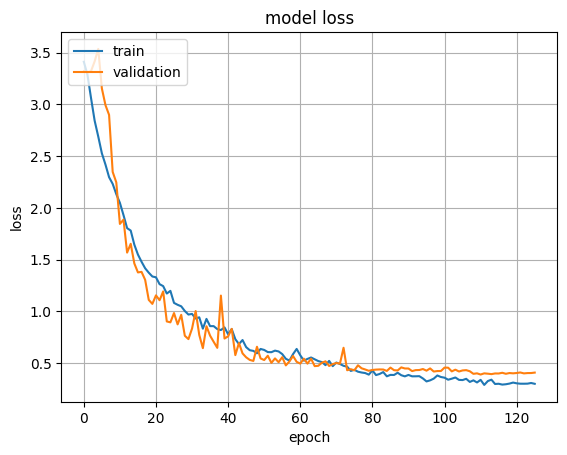

In [12]:
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.grid(True)
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
# salvando o modelo e seus pesos
cnn_model.save('../model/cnn_dinamica.h5')
cnn_model.save_weights('../model/cnn_dinamica.weights.h5')

# salvar o history
history_df = pd.DataFrame(cnn_history.history)
history_df.to_csv('../output/cnn_dinamica_history.csv', index=False)